In [1]:
import torch
import timm

# import pandas as pd
# import os
import matplotlib.pyplot as plt

# import numpy as np
# import pandas as pd
from torchvision import transforms

# from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torchvision

mps_device = torch.device("mps")

BATCH_SIZE = 16 * 2 * 2 * 2
# torch.manual_seed(0)
# random.seed(0)
# np.random.seed(0)

# if "converted" not in os.listdir():
#     os.mkdir("converted/")

/Users/wiktorjurkiewicz/repos/PROJECT/vrije/02_CODE/vrije-machine-learning-project/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform = transforms.Compose(
    transforms=[
        transforms.ToTensor(),
        transforms.Resize(size=38),
    ]
)

train_data = torchvision.datasets.MNIST("./", train=True, transform=transform, download=True)
test_data_xy = torchvision.datasets.MNIST("./", train=False, transform=transform, download=True)

train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
validation_dataloader = torch.utils.data.DataLoader(test_data_xy, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

In [3]:
class ConvNext(nn.Module):
    def __init__(self, n_classes, pretrained=True):

        super(ConvNext, self).__init__()

        self.model = timm.create_model("convnext_tiny", pretrained=False, in_chans=1)
        # if pretrained:
            # self.model.load_state_dict(torch.load("../input/timm-convnext-xcit/convnext_small_384_in22ft1k.pth"))
        self.model.head.fc = nn.Linear(self.model.head.fc.in_features, n_classes)
        
    def forward(self, x):
        x = self.model(x)
        return x

epoch = 25
convnext_model = ConvNext(10, pretrained=False).to(mps_device)
loss_history = [[], []] #train, val
accuracy_history = [[], []] #train, val
acc_epoch_history = [[],[]]
loss_epoch_history = [[],[]]

optimizer = torch.optim.Adam(convnext_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [4]:
for e in range(epoch):
    convnext_model.train()
    print(f"====================== EPOCH {e+1} ======================")
    print("Training.....")
    for i, (data, target) in enumerate(train_dataloader):
        target = target.to(mps_device)
        optimizer.zero_grad()
        output = convnext_model(data.to(mps_device))
        loss = criterion(output, F.one_hot(target, num_classes=10).type(torch.float))
        loss.backward()
        
        nn.utils.clip_grad_norm_(convnext_model.parameters(), 3)
        accuracy = (output.argmax(dim=1) == target).float().mean()
        
        loss_history[0].append(loss.item())
        accuracy_history[0].append(accuracy)
        
        optimizer.step()
        
        print(f"MINIBATCH {i+1}/{train_dataloader.__len__()} TRAIN ACC : {accuracy_history[0][-1]}  TRAIN LOSS : {loss_history[0][-1]}")
            
    

====================== EPOCH 1 ======================
Training.....
MINIBATCH 1/469 TRAIN ACC : 0.09375  TRAIN LOSS : 2.4478869438171387
MINIBATCH 2/469 TRAIN ACC : 0.1015625  TRAIN LOSS : 2.6704487800598145
MINIBATCH 3/469 TRAIN ACC : 0.21875  TRAIN LOSS : 3.5145316123962402
MINIBATCH 4/469 TRAIN ACC : 0.25  TRAIN LOSS : 2.8834924697875977
MINIBATCH 5/469 TRAIN ACC : 0.28125  TRAIN LOSS : 3.541382312774658
MINIBATCH 6/469 TRAIN ACC : 0.40625  TRAIN LOSS : 2.2255191802978516
MINIBATCH 7/469 TRAIN ACC : 0.5546875  TRAIN LOSS : 1.4844144582748413
MINIBATCH 8/469 TRAIN ACC : 0.5859375  TRAIN LOSS : 1.2304086685180664
MINIBATCH 9/469 TRAIN ACC : 0.6796875  TRAIN LOSS : 0.9906502962112427
MINIBATCH 10/469 TRAIN ACC : 0.7890625  TRAIN LOSS : 0.8041380047798157
MINIBATCH 11/469 TRAIN ACC : 0.6875  TRAIN LOSS : 0.8505185842514038
MINIBATCH 12/469 TRAIN ACC : 0.828125  TRAIN LOSS : 0.5535538196563721
MINIBATCH 13/469 TRAIN ACC : 0.828125  TRAIN LOSS : 0.5205830335617065
MINIBATCH 14/469 TRAIN A

In [ ]:
# accuracy_history
# acc = []
# for x in accuracy_history[0]:
#     acc.append(x.item())

# import json
# with open('accuracy_history.json', 'w') as f:
    # json.dump(acc, f)



In [15]:

print("Validation.....")
convnext_model.eval()

with torch.no_grad():
    for i, (data, target) in enumerate(validation_dataloader):
        target = target.to(mps_device)
        output = convnext_model(data.to(mps_device))
        loss = criterion(output, F.one_hot(target, num_classes=10).type(torch.float))

        accuracy = (output.argmax(dim=1) == target).float().mean()
        loss_history[1].append(loss.item())
        accuracy_history[1].append(accuracy)
    
acc_epoch_history[0].append(sum(accuracy_history[0][-1:-train_dataloader.__len__():-1])/train_dataloader.__len__())
acc_epoch_history[1].append(sum(accuracy_history[1][-1:-validation_dataloader.__len__():-1])/validation_dataloader.__len__())

loss_epoch_history[0].append(sum(loss_history[0][-1:-train_dataloader.__len__():-1])/train_dataloader.__len__())
loss_epoch_history[1].append(sum(loss_history[1][-1:-validation_dataloader.__len__():-1])/validation_dataloader.__len__())

print("====================================================")
print(f"TRAIN ACC : {acc_epoch_history[0][-1]}  TRAIN LOSS : {loss_epoch_history[0][-1]}")
print(f"VALL ACC : {acc_epoch_history[1][-1]}  VAL LOSS : {loss_epoch_history[1][-1]}")
print("====================================================")

# torch.save({
#         'epoch': e,
#         'model_state_dict': convnext_model.state_dict(),
#         'optimizer_state_dict': optimizer.state_dict(),
#         # 'loss': loss_epoch_history[0][-1],
#         # 'acc' : acc_epoch_history[0][-1]
#         }, './model_checkpoint.pt')

Validation.....
TRAIN ACC : 0.9964852333068848  TRAIN LOSS : 0.004422504082059647
VALL ACC : 0.9772547483444214  VAL LOSS : 0.04563539245706251


In [ ]:
import numpy as np



(25,)

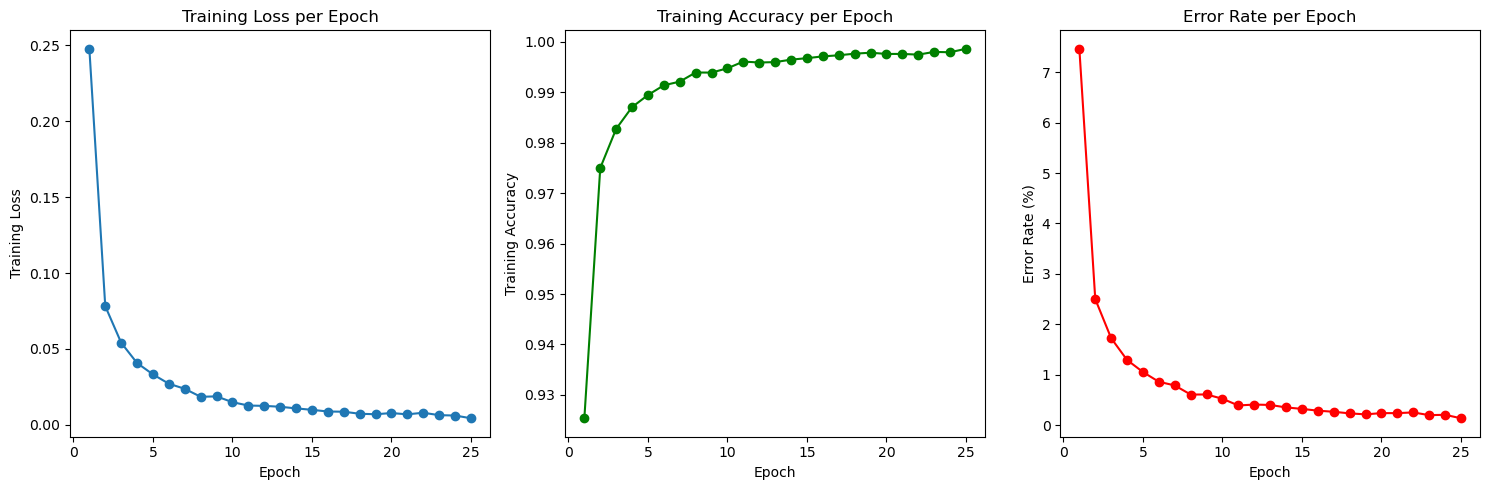

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

acc = []
for x in accuracy_history[0]:
    acc.append(x.item())

epochs = np.arange(1, 25 + 1)
b = np.mean(np.array(acc).reshape((25, -1)), axis=1)
error_rates = [(1 - acc) * 100 for acc in b]


plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(epochs, np.mean(np.array(loss_history[0]).reshape((25, -1)), axis=1), marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss per Epoch")

plt.subplot(1, 3, 2)
plt.plot(epochs, np.mean(np.array(acc).reshape((25, -1)), axis=1), marker="o", color="green")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy per Epoch")

plt.subplot(1,3,3)
plt.plot(epochs, error_rates, marker='o', color='red')
plt.xlabel("Epoch")
plt.ylabel("Error Rate (%)")
plt.title("Error Rate per Epoch")
plt.tight_layout()
plt.show()
